<a href="https://colab.research.google.com/github/adits09/EDA_PROJECT_ADITI/blob/main/Phase1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

#Loading Dataset
df = pd.read_csv("eda_lab.csv")
df.head()

,rownames,city,year,month,sales,volume,median,listings,inventory,date
0,1,Abilene,2000,1,72.0,5380000.0,71400.0,701.0,6.3,2000.000000
1,2,Abilene,2000,2,98.0,6505000.0,58700.0,746.0,6.6,2000.083333
2,3,Abilene,2000,3,130.0,9285000.0,58100.0,784.0,6.8,2000.166667
3,4,Abilene,2000,4,98.0,9730000.0,68600.0,785.0,6.9,2000.250000
4,5,Abilene,2000,5,141.0,10590000.0,67300.0,794.0,6.8,2000.333333


In [5]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8602 entries, 0 to 8601
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   rownames   8602 non-null   int64  
 1   city       8602 non-null   object 
 2   year       8602 non-null   int64  
 3   month      8602 non-null   int64  
 4   sales      8034 non-null   float64
 5   volume     8034 non-null   float64
 6   median     7986 non-null   float64
 7   listings   7178 non-null   float64
 8   inventory  7135 non-null   float64
 9   date       8602 non-null   float64
dtypes: float64(6), int64(3), object(1)
memory usage: 672.2+ KB


In [6]:
#Applying basic statistical analysis
df.describe()

,rownames,year,month,sales,volume,median,listings,inventory,date
count,8602.000000,8602.000000,8602.000000,8034.000000,8.034000e+03,7986.000000,7178.000000,7135.000000,8602.000000
mean,4301.500000,2007.299465,6.406417,549.564600,1.068586e+08,128131.442524,3216.902340,7.174590,2007.750000
std,2483.327841,4.502923,3.441932,1110.737179,2.449337e+08,37359.575317,5968.331072,4.612125,4.498718
min,1.000000,2000.000000,1.000000,6.000000,8.350000e+05,50000.000000,0.000000,0.000000,2000.000000
25%,2151.250000,2003.000000,3.000000,86.000000,1.084000e+07,100000.000000,682.000000,4.900000,2003.833333
50%,4301.500000,2007.000000,6.000000,169.000000,2.298682e+07,123800.000000,1283.000000,6.200000,2007.750000
75%,6451.750000,2011.000000,9.000000,467.000000,7.512139e+07,150000.000000,2953.750000,8.150000,2011.666667
max,8602.000000,2015.000000,12.000000,8945.000000,2.568157e+09,304200.000000,43107.000000,55.900000,2015.500000


In [12]:
df.describe(include="object")

,city
count,8602
unique,46
top,Abilene
freq,187


In [13]:
df.nunique()

,0
rownames,8602
city,46
year,16
month,12
sales,1711
volume,7494
median,1537
listings,3702
inventory,295
date,187


In [14]:
#Missing Value Analysis
df.isnull().sum()

,0
rownames,0
city,0
year,0
month,0
sales,568
volume,568
median,616
listings,1424
inventory,1467
date,0


In [16]:
#Handling Missing Data
print(df.isnull().sum())

rownames        0
city            0
year            0
month           0
sales         568
volume        568
median        616
listings     1424
inventory    1467
date            0
dtype: int64


In [17]:
# Fill missing numerical values with the median

df["sales"] = df["sales"].fillna(df["sales"].median())
df["volume"] = df["volume"].fillna(df["volume"].median())
df["median"] = df["median"].fillna(df["median"].median())
df["listings"] = df["listings"].fillna(df["listings"].median())
df["inventory"] = df["inventory"].fillna(df["inventory"].median())

In [18]:
print("Missing Values After Handling:")
print(df.isnull().sum())

Missing Values After Handling:
rownames     0
city         0
year         0
month        0
sales        0
volume       0
median       0
listings     0
inventory    0
date         0
dtype: int64


In [19]:
#Data Cleaning
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [20]:
# Display data types
print(df.dtypes)

rownames       int64
city          object
year           int64
month          int64
sales        float64
volume       float64
median       float64
listings     float64
inventory    float64
date         float64
dtype: object


In [22]:
# Check for incorrect Values

print("Negative Sales:", (df["sales"] < 0).sum())
print("Negative Volume:", (df["volume"] < 0).sum())
print("Negative Median:", (df["median"] < 0).sum())
print("Negative Listings:", (df["listings"] < 0).sum())
print("Negative Inventory:", (df["inventory"] < 0).sum())

Negative Sales: 0
Negative Volume: 0
Negative Median: 0
Negative Listings: 0
Negative Inventory: 0


In [23]:
#Check for Inconsistent Categories
print(df["city"].unique())

['Abilene' 'Amarillo' 'Arlington' 'Austin' 'Bay Area' 'Beaumont'
 'Brazoria County' 'Brownsville' 'Bryan-College Station' 'Collin County'
 'Corpus Christi' 'Dallas' 'Denton County' 'El Paso' 'Fort Bend'
 'Fort Worth' 'Galveston' 'Garland' 'Harlingen' 'Houston' 'Irving'
 'Kerrville' 'Killeen-Fort Hood' 'Laredo' 'Longview-Marshall' 'Lubbock'
 'Lufkin' 'McAllen' 'Midland' 'Montgomery County' 'Nacogdoches'
 'NE Tarrant County' 'Odessa' 'Paris' 'Port Arthur' 'San Angelo'
 'San Antonio' 'San Marcos' 'Sherman-Denison' 'South Padre Island'
 'Temple-Belton' 'Texarkana' 'Tyler' 'Victoria' 'Waco' 'Wichita Falls']


In [24]:
# Remove leading/trailing spaces from city names

df["city"] = df["city"].str.strip()

In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8602 entries, 0 to 8601
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   rownames   8602 non-null   int64         
 1   city       8602 non-null   object        
 2   year       8602 non-null   int64         
 3   month      8602 non-null   int64         
 4   sales      8602 non-null   float64       
 5   volume     8602 non-null   float64       
 6   median     8602 non-null   float64       
 7   listings   8602 non-null   float64       
 8   inventory  8602 non-null   float64       
 9   date       8602 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(3), object(1)
memory usage: 672.2+ KB
None


In [27]:
# Data Deduplication

# Check duplicate rows
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows before removal:", duplicate_rows)

# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape:", df.shape)

Number of duplicate rows before removal: 0
Dataset shape: (8602, 10)


In [28]:
#Replacing Values
month_mapping = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

df["month"] = df["month"].replace(month_mapping)

In [30]:
#Dropping Missing Values
print("Shape before dropping missing values:", df.shape)

df = df.dropna()

print("Shape after dropping missing values:", df.shape)

Shape before dropping missing values: (8602, 10)
Shape after dropping missing values: (8602, 10)


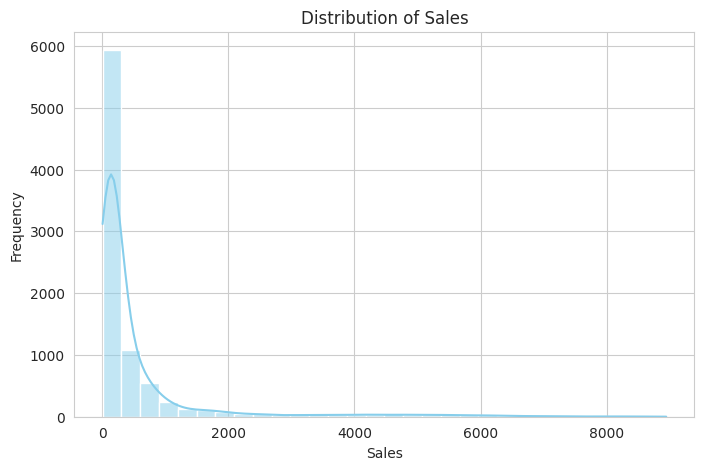

In [32]:
#Univariate Analysis
#1. Distribution of Sales
plt.figure(figsize=(8,5))

sns.histplot(df["sales"], bins=30, kde=True, color="skyblue")

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

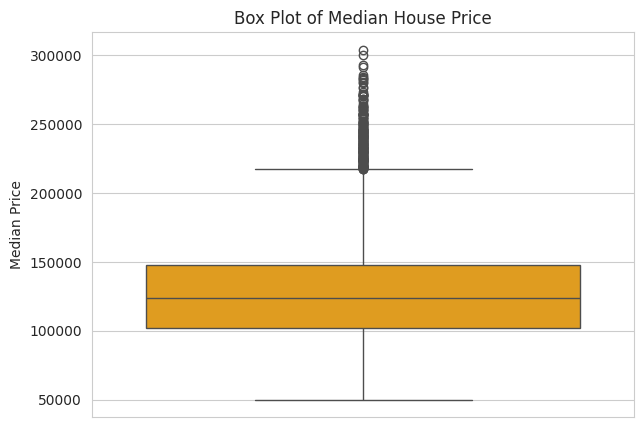

In [33]:
#2. Median House Price
plt.figure(figsize=(7,5))

sns.boxplot(y=df["median"], color="orange")

plt.title("Box Plot of Median House Price")
plt.ylabel("Median Price")

plt.show()

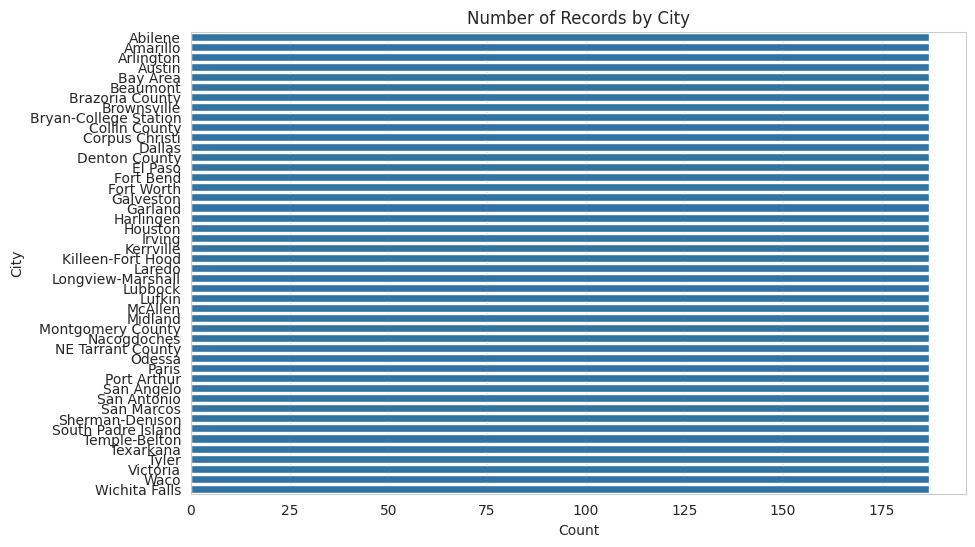

In [34]:
#3. Number of Records by City
plt.figure(figsize=(10,6))

sns.countplot(
    y="city",
    data=df,
    order=df["city"].value_counts().index
)

plt.title("Number of Records by City")
plt.xlabel("Count")
plt.ylabel("City")

plt.show()

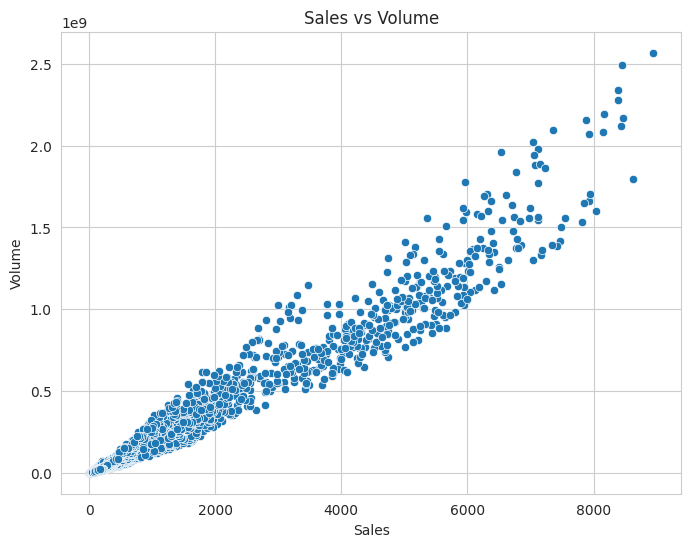

In [35]:
#Bivariate Analysis
#1. Sales vs Volume
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="sales",
    y="volume",
    data=df
)

plt.title("Sales vs Volume")
plt.xlabel("Sales")
plt.ylabel("Volume")

plt.show()

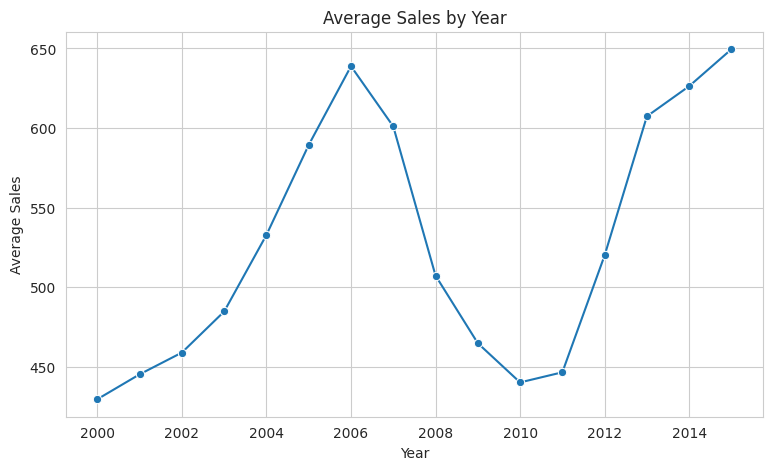

In [37]:
#2. Average Sales by Year
plt.figure(figsize=(9,5))

sales_year = df.groupby("year")["sales"].mean().reset_index()

sns.lineplot(
    data=sales_year,
    x="year",
    y="sales",
    marker="o"
)

plt.title("Average Sales by Year")
plt.xlabel("Year")
plt.ylabel("Average Sales")

plt.show()

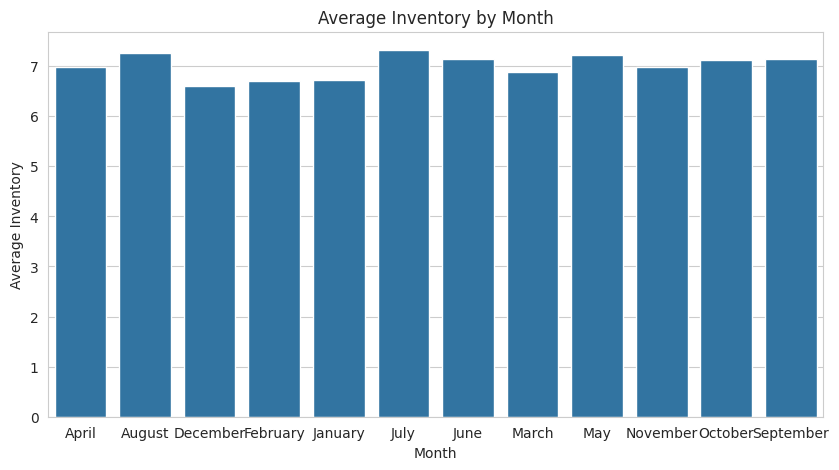

In [38]:
#3. Inventory by Month
plt.figure(figsize=(10,5))

inventory_month = df.groupby("month")["inventory"].mean().reset_index()

sns.barplot(
    data=inventory_month,
    x="month",
    y="inventory"
)

plt.title("Average Inventory by Month")
plt.xlabel("Month")
plt.ylabel("Average Inventory")

plt.show()

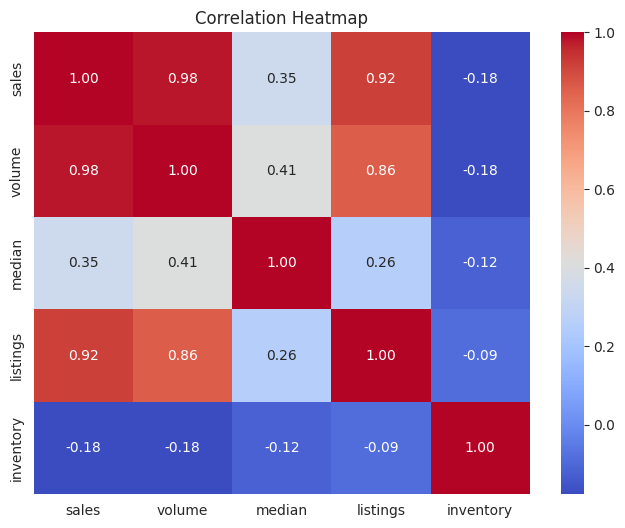

In [39]:
#Multivariate Analysis
#1. Correlation Heatmap
plt.figure(figsize=(8,6))

corr = df[["sales", "volume", "median", "listings", "inventory"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

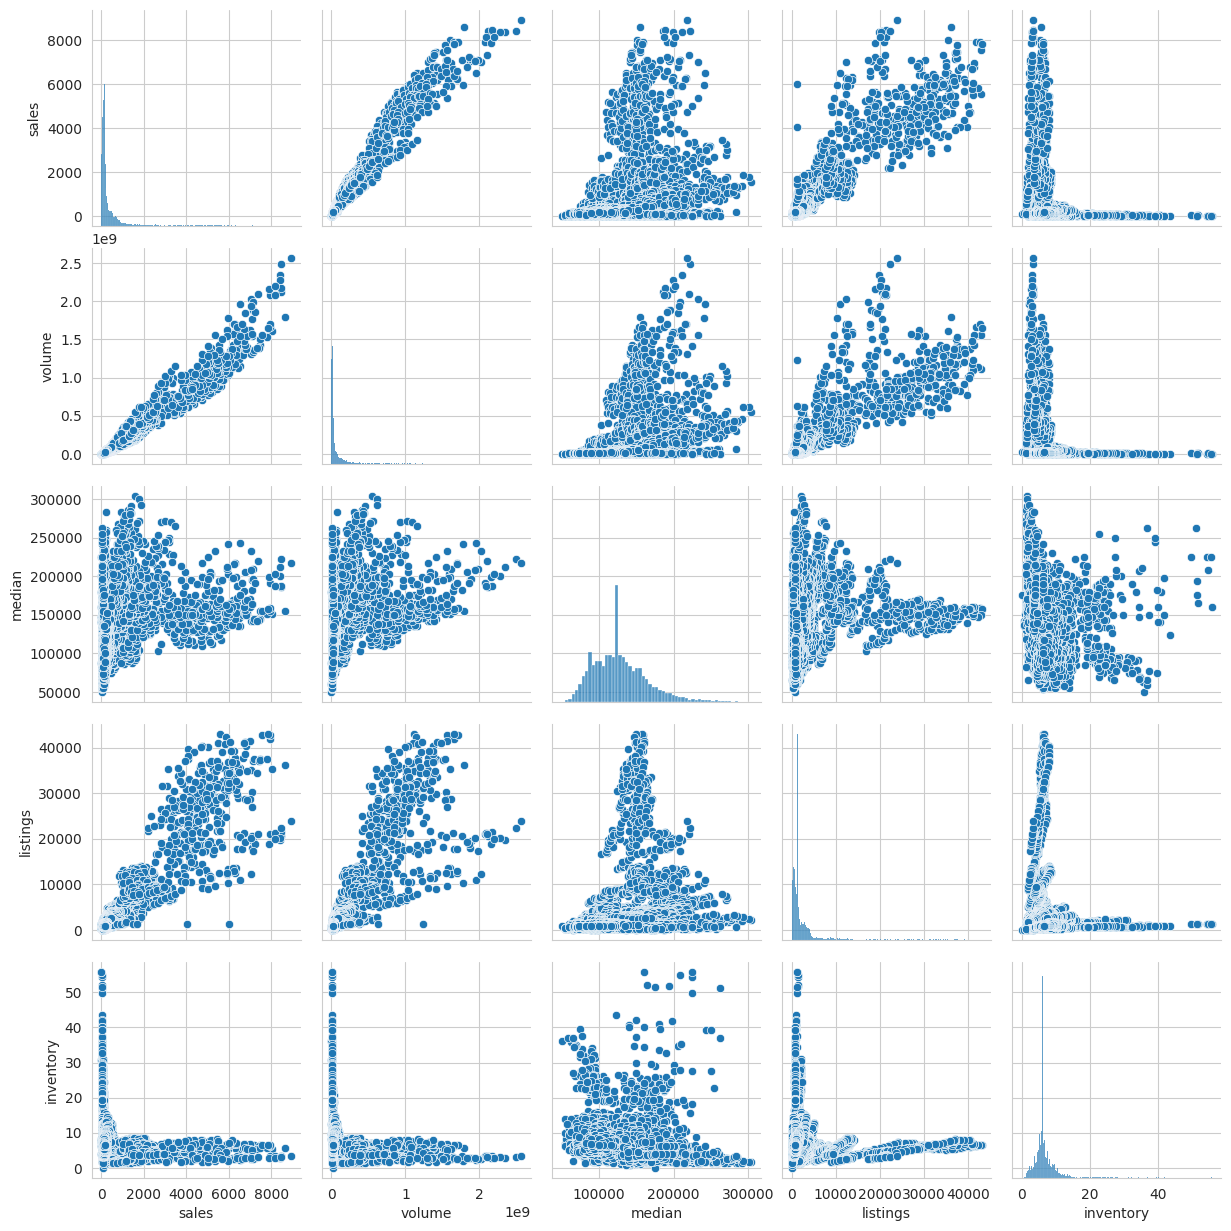

In [40]:
#2. Pair Plot
sns.pairplot(
    df[["sales", "volume", "median", "listings", "inventory"]]
)

plt.show()

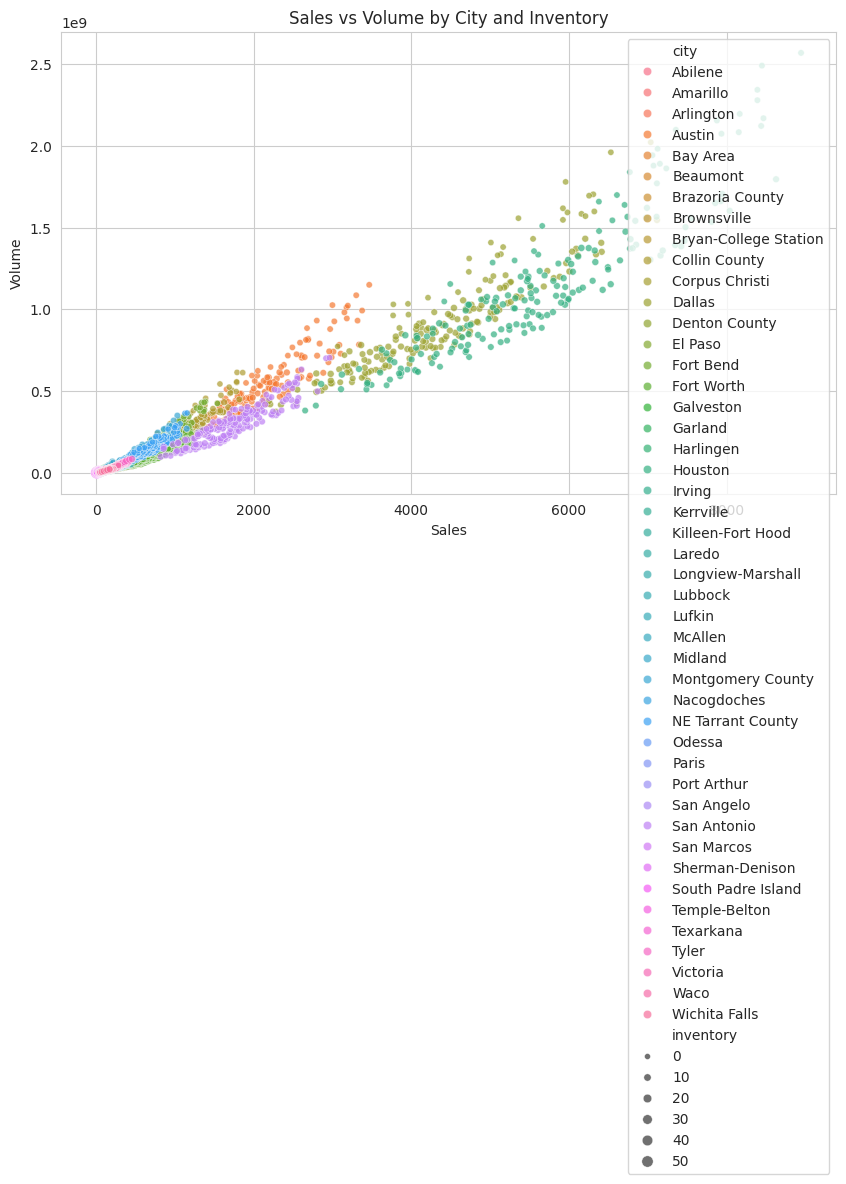

In [41]:
#3: Sales vs Volume by City
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="sales",
    y="volume",
    hue="city",
    size="inventory",
    alpha=0.7
)

plt.title("Sales vs Volume by City and Inventory")
plt.xlabel("Sales")
plt.ylabel("Volume")

plt.show()